# 01 - Logistic Regression

**Owner:** Member A

**Inputs:** preprocessed splits produced by `00_eda_and_preprocessing.ipynb`
(`artifacts/splits/splits.npz`). Do not re-split or re-scale here.

**Outputs:** `artifacts/results/logistic_regression.json`,
`artifacts/models/logistic_regression.joblib`,
plus ROC / PR / confusion-matrix PNGs in `figures/`.

**Why this model**

Logistic Regression is the **interpretable linear baseline** for this project. Its coefficients map one-to-one with the (log-scaled, z-scored) features, so we can read off the direction and magnitude of each behaviour's contribution to the fraud score. We do **not** expect it to win on F1 against the tree models, but if it lands within a few points of XGBoost we have a strong story about feature linearity in the report (§12 of the plan).

The structure below is identical across the five model notebooks:
1. Load shared splits.
2. **Variant A** — model with built-in imbalance handling (`class_weight`, `scale_pos_weight`, or distance weighting).
3. **Variant B** — SMOTE oversampling on training folds only (via `imblearn.pipeline.Pipeline`).
4. Pick the variant with the higher CV F1, refit, evaluate on the held-out test set.
5. Save the result JSON + the fitted model.


## 1. Setup & load shared splits

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import load_splits
from src.tuning import grid_search, random_search, CV
from src.evaluation import (
    evaluate, save_results, print_metric_table,
    plot_confusion, plot_roc, plot_pr, _scores,
)

SPLITS_DIR  = PROJECT_ROOT / "artifacts" / "splits"
MODELS_DIR  = PROJECT_ROOT / "artifacts" / "models"
RESULTS_DIR = PROJECT_ROOT / "artifacts" / "results"
FIG_DIR     = PROJECT_ROOT / "figures"
for d in (MODELS_DIR, RESULTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

data = load_splits(SPLITS_DIR)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
feature_names   = data["feature_names"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"train fraud rate: {y_train.mean():.4f}, test fraud rate: {y_test.mean():.4f}")


X_train: (7430, 45), X_test: (1858, 45)
train fraud rate: 0.1783, test fraud rate: 0.1781


## 2. ### Variant A: `class_weight='balanced'`

Reweights the loss so the minority (fraud) class contributes more per sample. No synthetic data, no extra moving parts. The grid ranges over L1 (sparse) and L2 (ridge) penalties with `liblinear` as the solver, plus four orders of magnitude of regularization.

In [2]:
from sklearn.linear_model import LogisticRegression

estimator_cw = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=42,
    class_weight="balanced",
)

grid_cw = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l1", "l2"],
}

search_cw = grid_search(estimator_cw, grid_cw)
search_cw.fit(X_train, y_train)
print(f"Variant A best CV F1: {search_cw.best_score_:.4f}  params: {search_cw.best_params_}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

Variant A best CV F1: 0.7207  params: {'C': 10.0, 'penalty': 'l1'}


## 3. ### Variant B: SMOTE oversampling

SMOTE generates synthetic minority points by interpolating between nearest neighbours **inside each CV training fold only** (this is what `imblearn.pipeline.Pipeline` guarantees). The estimator runs on the rebalanced data; no `class_weight` is needed.

In [3]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipe_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   LogisticRegression(solver="liblinear", max_iter=2000, random_state=42)),
])

grid_smote = {
    "clf__C":       [0.01, 0.1, 1.0, 10.0],
    "clf__penalty": ["l1", "l2"],
}

search_smote = grid_search(pipe_smote, grid_smote)
search_smote.fit(X_train, y_train)
print(f"Variant B best CV F1: {search_smote.best_score_:.4f}  params: {search_smote.best_params_}")


Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/pyth

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarnin

...

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Variant B best CV F1: 0.7414  params: {'clf__C': 10.0, 'clf__penalty': 'l1'}


## 4. Pick the better variant, refit & evaluate on test

In [4]:
# Pick the variant with the better CV F1 score
variants = {
    "class_weight": search_cw,
    "smote":        search_smote,
}
best_variant = max(variants, key=lambda k: variants[k].best_score_)
best_search  = variants[best_variant]
best_model   = best_search.best_estimator_

print(f"\nWinning variant: {best_variant}")
print(f"  CV F1 (winning):       {best_search.best_score_:.4f}")
print(f"  CV F1 (other variant): {variants['smote' if best_variant=='class_weight' else 'class_weight'].best_score_:.4f}")
print(f"  Best params:           {best_search.best_params_}")

# Final evaluation on the held-out test set
results = evaluate(
    best_model,
    X_train, y_train, X_test, y_test,
    model_name="logistic_regression",
    best_params=best_search.best_params_,
    imbalance_strategy=best_variant,
)
print_metric_table(results)

save_results(results, RESULTS_DIR / "logistic_regression.json")
joblib.dump(best_model, MODELS_DIR / "logistic_regression.joblib")
print(f"\nSaved -> artifacts/results/logistic_regression.json + artifacts/models/logistic_regression.joblib")



Winning variant: smote
  CV F1 (winning):       0.7414
  CV F1 (other variant): 0.7207
  Best params:           {'clf__C': 10.0, 'clf__penalty': 'l1'}

=== logistic_regression (smote) ===
Best params: {'clf__C': 10.0, 'clf__penalty': 'l1'}
metric                   train      test
accuracy                0.8869    0.8843
balanced_accuracy       0.8969    0.8799
precision               0.6255    0.6255
recall                  0.9125    0.8731
f1                      0.7422    0.7289
roc_auc                 0.9597    0.9408
pr_auc                  0.8302    0.8284
Confusion matrix (test):
[[1354  173]
 [  42  289]]

Saved -> artifacts/results/logistic_regression.json + artifacts/models/logistic_regression.joblib


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

## 5. Diagnostic plots

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


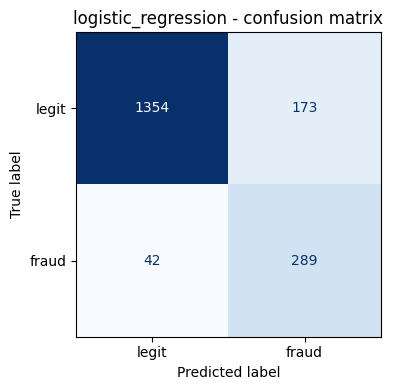

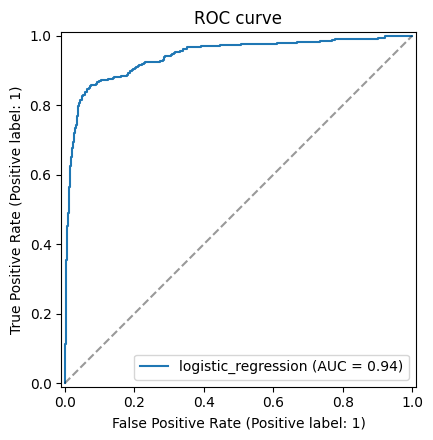

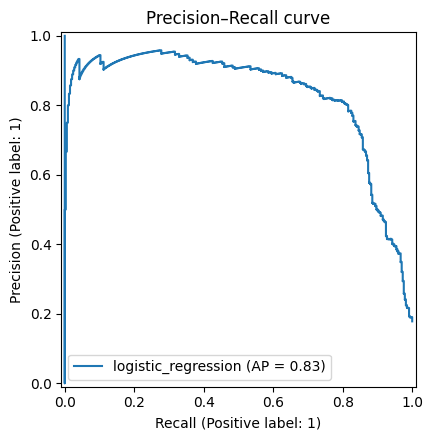

In [5]:
# Diagnostic plots
y_pred = best_model.predict(X_test)
y_score = _scores(best_model, X_test)

fig_cm = plot_confusion(y_test, y_pred, title=f"{results['model_name']} - confusion matrix")
fig_cm.savefig(FIG_DIR / "logistic_regression_confusion.png", bbox_inches="tight")
plt.show()

if y_score is not None:
    fig_roc = plot_roc(y_test, y_score, label="logistic_regression")
    fig_roc.savefig(FIG_DIR / "logistic_regression_roc.png", bbox_inches="tight")
    plt.show()

    fig_pr = plot_pr(y_test, y_score, label="logistic_regression")
    fig_pr.savefig(FIG_DIR / "logistic_regression_pr.png", bbox_inches="tight")
    plt.show()


## 6. Hand-off to the comparison notebook

`artifacts/results/logistic_regression.json` now contains:

```
model_name, imbalance_strategy, best_params,
train: {accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc},
test:  {accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc},
confusion_matrix_test
```

`06_comparison_and_interpretation.ipynb` will read this file (alongside the
other four) to build the comparison table and overlay the ROC / PR curves.